In [ ]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.preprocessing.grid_sampling_undersample import create_triclass_balanced_grid

In [15]:
# Configure paths
INPUT_RASTER = '/content/drive/MyDrive/Fine-Tuning-Workflow/Downloads/S2/reference_labels_partidos_AMBA.tif'
OUTPUT_GRID = '/content/drive/MyDrive/Fine-Tuning-Workflow/Downloads/S2/grid_partidos_amba.geojson'
AOI = "/content/drive/MyDrive/Fine-Tuning-Workflow/Data/partidos_amba_IA_BID_2025.geojson"
# Run grid creation
grid_path =  create_triclass_balanced_grid(
    input_raster=INPUT_RASTER,
    output_path=OUTPUT_GRID,
    patch_size=128,
    class_ratios=[1, 4, 0.7],       # ✅ Equal representation
    min_class_pct=5.0,           # Patch must be ≥30% one class to count
    splits=(0.7, 0.15, 0.15),
    random_seed=42,
    aoi_path=AOI
)

print(f"\n✅ Grid saved to: {grid_path}")

🔍 Creating grid and calculating class distributions...
📍 AOI loaded: 1 feature(s)
   Filtered by AOI: 8248/20586 patches kept

✅ Initial grid created: 8248 total patches
   Patches by dominant class:
     Class 0: 363 patches
     Class 1: 7,846 patches
     Class 2: 39 patches

🎯 Balancing classes...

📊 Available patches by dominant class:
  Class 0: 363 patches
  Class 1: 7,846 patches
  Class 2: 39 patches

🎯 Target ratios [Class0:Class1:Class2] = [1, 4, 0.7]
   Based on rarest class: 39 patches
  ✅ Class 0: Sampled 55 from 363 available
  ✅ Class 1: Sampled 222 from 7,846 available
  ✅ Class 2: Sampled 39 from 39 available

📈 FINAL DATASET STATISTICS

1. Split sizes:
   Train :  220 patches ( 69.6%)
   Val   :   47 patches ( 14.9%)
   Test  :   49 patches ( 15.5%)

2. Overall class distribution:
   Class 0:   55 patches ( 17.4%)
   Class 1:  222 patches ( 70.3%)
   Class 2:   39 patches ( 12.3%)

3. Class distribution per split:
   Train:
      Class 0:   38 ( 17.3%)
      Class 1:

Total patches: 316

Columns available: ['dominant_class', 'class_0_pct', 'class_1_pct', 'class_2_pct', 'dominant_pct', 'class_counts', 'is_pure', 'patch_id', 'set', 'geometry']

✅ Using triclass balanced grid

Class distribution:
dominant_class
0     55
1    222
2     39
Name: count, dtype: int64


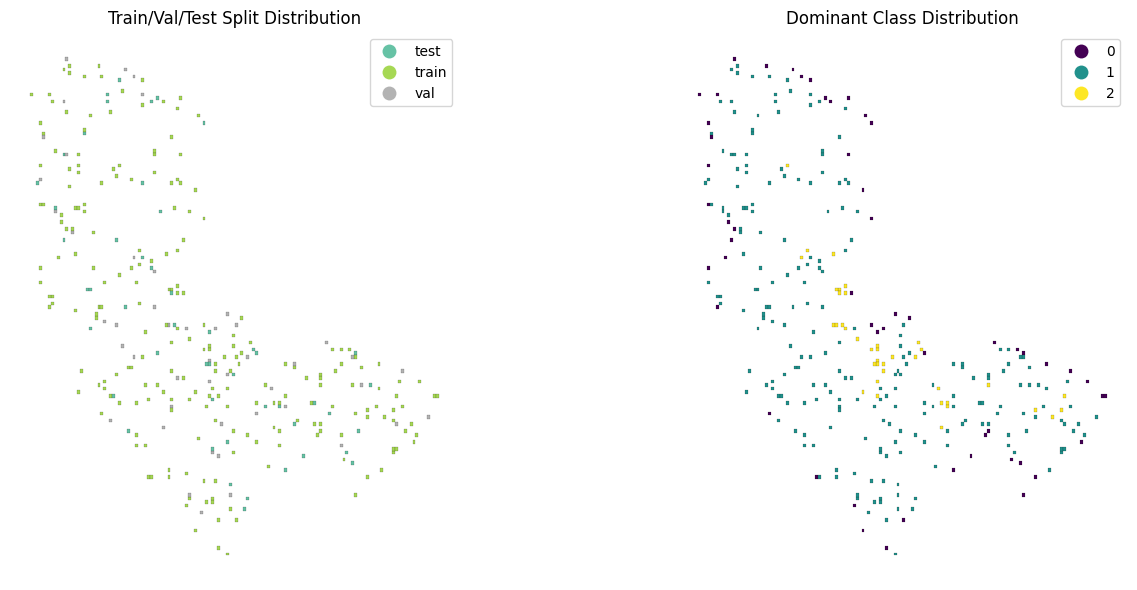

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the created grid
grid = gpd.read_file("/content/drive/MyDrive/Fine-Tuning-Workflow/Downloads/S2/grid_partidos_amba.geojson")

print(f"Total patches: {len(grid)}")
print(f"\nColumns available: {grid.columns.tolist()}")

# ✅ Detect which column exists and use it
if 'has_minority' in grid.columns:
    minority_col = 'has_minority'
    label = 'Minority classes'
elif 'has_class_2' in grid.columns:
    minority_col = 'has_class_2'
    label = 'Class 2'
elif 'dominant_class' in grid.columns:
    # This is from the triclass balanced script
    print("\n✅ Using triclass balanced grid")
    print(f"\nClass distribution:")
    print(grid['dominant_class'].value_counts().sort_index())
    minority_col = None
else:
    print("⚠️ No recognized class column found!")
    minority_col = None

# Convert string to boolean if needed
if minority_col and grid[minority_col].dtype == 'object':
    grid[minority_col] = grid[minority_col].map({
        'True': True, 'False': False,
        True: True, False: False
    })

# Print distribution
if minority_col:
    print(f"\n{'='*60}")
    print(f"{label} Distribution:")
    print(f"{'='*60}")
    for split in ['train', 'val', 'test']:
        split_data = grid[grid['set'] == split]
        target_count = len(split_data[split_data[minority_col]])
        total = len(split_data)
        pct = (target_count / total * 100) if total > 0 else 0
        print(f"{split.capitalize():6s}: {target_count:4d}/{total:4d} ({pct:.1f}%)")

# Visualize based on what's available
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Split distribution
grid.plot(column='set', ax=axes[0], legend=True,
          categorical=True, cmap='Set2', edgecolor='black', linewidth=0.1)
axes[0].set_title('Train/Val/Test Split Distribution')
axes[0].axis('off')

# Plot 2: Class distribution
if 'dominant_class' in grid.columns:
    # Triclass balanced grid
    grid.plot(column='dominant_class', ax=axes[1], legend=True,
              categorical=True, cmap='viridis', edgecolor='black', linewidth=0.1)
    axes[1].set_title('Dominant Class Distribution')
elif minority_col:
    # Binary minority/dominant grid
    grid.plot(column=minority_col, ax=axes[1], legend=True,
              categorical=True, cmap='RdYlGn', edgecolor='black', linewidth=0.1)
    axes[1].set_title(f'{label} Presence')
else:
    axes[1].text(0.5, 0.5, 'No class column found',
                 ha='center', va='center', fontsize=14)

axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/grid_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
grid

,dominant_class,class_0_pct,class_1_pct,class_2_pct,dominant_pct,class_counts,is_pure,patch_id,set,geometry
0,0,95.60,4.40,0.00,95.60,"{0: 15663, 1: 721}",True,69,train,"POLYGON ((-58.51581 -34.65727, -58.51581 -34.6..."
1,0,75.87,24.13,0.00,75.87,"{0: 12431, 1: 3953}",True,112,train,"POLYGON ((-59.27471 -33.93287, -59.27471 -33.9..."
2,0,94.01,5.99,0.00,94.01,"{0: 15402, 1: 982}",True,83,val,"POLYGON ((-58.97575 -33.85238, -58.97575 -33.8..."
3,0,60.61,39.39,0.00,60.61,"{0: 9930, 1: 6454}",True,51,train,"POLYGON ((-58.88376 -35.1747, -58.88376 -35.16..."
4,0,98.04,1.96,0.00,98.04,"{0: 16063, 1: 321}",True,42,train,"POLYGON ((-58.66529 -34.02486, -58.66529 -34.0..."
...,...,...,...,...,...,...,...,...,...,...
112,2,0.49,41.03,58.48,58.48,"{0: 80, 1: 6722, 2: 9582}",True,36,train,"POLYGON ((-58.49281 -34.78376, -58.49281 -34.7..."
113,2,1.10,45.86,53.04,53.04,"{0: 180, 1: 7514, 2: 8690}",True,95,test,"POLYGON ((-58.79177 -34.57678, -58.79177 -34.5..."
114,2,10.16,27.41,62.43,62.43,"{0: 1664, 1: 4491, 2: 10229}",True,4,train,"POLYGON ((-58.48131 -34.73776, -58.48131 -34.7..."
115,2,0.00,45.51,54.49,54.49,"{1: 7456, 2: 8928}",True,15,train,"POLYGON ((-58.40082 -34.88724, -58.40082 -34.8..."


In [ ]:
grid = gpd.read_file("/content/drive/MyDrive/Fine-Tuning-Workflow/Downloads/S2/grid_partidos_amba.geojson")
grid

KeyError: 'has_minority'

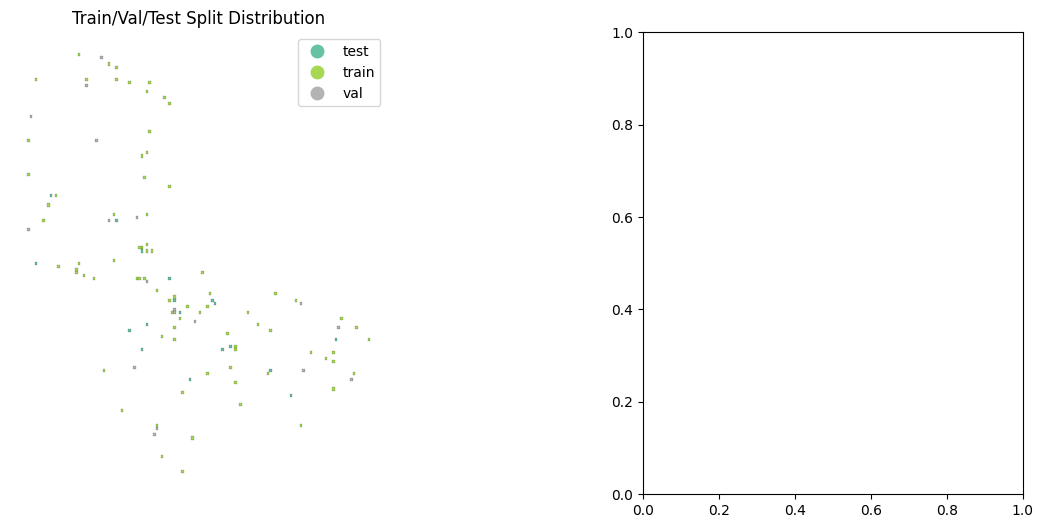

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Split distribution
grid.plot(column='set', ax=axes[0], legend=True,
          categorical=True, cmap='Set2', edgecolor='black', linewidth=0.1)
axes[0].set_title('Train/Val/Test Split Distribution')
axes[0].axis('off')

# Plot 2: Class 2 presence
grid.plot(column='has_minority', ax=axes[1], legend=True,
          categorical=True, cmap='RdYlGn', edgecolor='black', linewidth=0.1)
axes[1].set_title('Class 2 Presence (Target Class)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/grid_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd

# Fix boolean si es necesario
if grid['has_minority'].dtype == 'object':
    grid['has_minority'] = grid['has_minority'].map({'True': True, 'False': False, True: True, False: False})

# Sample estratificado del 10% - UNA LÍNEA!
sampled_grid = grid.groupby(['set', 'has_minority'], group_keys=False).apply(
    lambda x: x.sample(frac=0.5, random_state=42)
)

print(f"Original: {len(grid)} patches")
print(f"Sample:   {len(sampled_grid)} patches")

# Verificar distribución
print("\nClass 2 distribution:")
for split in ['train', 'val', 'test']:
    split_data = sampled_grid[sampled_grid['set'] == split]
    class2_count = len(split_data[split_data['has_minority']])
    total = len(split_data)
    pct = (class2_count / total * 100) if total > 0 else 0
    print(f"{split.capitalize():6s}: {class2_count:4d}/{total:4d} ({pct:.1f}% class 2)")

# Guardar
sampled_grid.to_file("/content/drive/MyDrive/Fine-Tuning-Workflow/Downloads/S2/grid_partidos_amba_sample_50.geojson", driver='GeoJSON')

In [ ]:
sampled_grid

In [17]:
import pandas as pd
from collections import Counter
import ast

# Agregar todos los class_counts parseando correctamente
all_class_counts = Counter()

for class_dict in grid['class_counts']:
    if class_dict is not None:
        # Si es string, convertir a dict
        if isinstance(class_dict, str):
            try:
                class_dict = ast.literal_eval(class_dict)
            except:
                continue

        # Ahora sí actualizar el contador
        if isinstance(class_dict, dict):
            all_class_counts.update(class_dict)

# Calcular totales y porcentajes
total_pixels = sum(all_class_counts.values())

print(f"{'='*60}")
print(f"TOTAL PIXEL DISTRIBUTION ACROSS ALL PATCHES")
print(f"{'='*60}")
print(f"\nTotal pixels: {total_pixels:,}")
print(f"\nClass distribution:")
print(f"{'Class':<10} {'Pixels':<15} {'Percentage':<15}")
print(f"{'-'*40}")

for class_id in sorted(all_class_counts.keys()):
    count = all_class_counts[class_id]
    pct = (count / total_pixels * 100)
    print(f"{class_id:<10} {count:<15,} {pct:<15.2f}%")

# Versión más visual
print(f"\n{'='*60}")
print("Visual representation:")
for class_id in sorted(all_class_counts.keys()):
    count = all_class_counts[class_id]
    pct = (count / total_pixels * 100)
    bar = '█' * int(pct)
    print(f"Class {class_id}: {bar} {pct:.2f}%")

# Bonus: Mostrar el imbalance ratio
if 2 in all_class_counts:
    class2_pct = (all_class_counts[2] / total_pixels * 100)
    print(f"\n{'='*60}")
    print(f"Class 2 (target) represents: {class2_pct:.2f}% of all pixels")
    print(f"Imbalance ratio: 1:{int(100/class2_pct)} (1 class 2 pixel per {int(100/class2_pct)} total pixels)")

TOTAL PIXEL DISTRIBUTION ACROSS ALL PATCHES

Total pixels: 5,168,512

Class distribution:
Class      Pixels          Percentage     
----------------------------------------
0          771,440         14.93          %
1          3,948,212       76.39          %
2          448,860         8.68           %

Visual representation:
Class 0: ██████████████ 14.93%
Class 1: ████████████████████████████████████████████████████████████████████████████ 76.39%
Class 2: ████████ 8.68%

Class 2 (target) represents: 8.68% of all pixels
Imbalance ratio: 1:11 (1 class 2 pixel per 11 total pixels)
